In [1]:
import os

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# !conda install -y -c conda-forge pandas geopandas matplotlib numpy shapely contextily openpyxl

### Specific util functions

In [3]:
# def clean_hh_geoid(geoid):
#     """
#     Homelands census datasets have core geoid identifier while geojson uses the full geoid.
#     e.g. Waiamanlo is represented as 155271T in geojson and 5271 in census datasets.
#     Process geojson GEOID10 to match census dataset format for geoid
#     """
#     if isinstance(geoid, str):
#         if geoid.startswith('15'):
#             geoid = geoid[2:]
#         if geoid.endswith('T'):
#             geoid = geoid[:-1]
#     return geoid

In [4]:
# census_data = pd.read_csv(f'./age_of_structure.csv')

# # census_data = pd.read_csv(f'/home/shared/SCOVI/cleaned-data/census/age_of_structure.csv')

# print(f"Shape: {census_data.shape}")
# print(census_data.head(2))
# print("\nColumn names:")
# print(census_data.columns.tolist())

### Read shp to gdf

In [20]:
# file = "On-site_Sewage_Disposal_Systems_-_Oahu"
# gdf = gpd.read_file(f'~/Desktop/GIS Data/done/On-site_Sewage_Disposal_Systems_-_Molokai/On-site_Sewage_Disposal_Systems_-_Molokai.shp')
gdf = gpd.read_file(f'~/Desktop/GIS Data/done/Census_Hawaiian_Homelands_hhl10/hhl10.shp')
# gdf = gpd.read_file(f'~/Desktop/GIS Data/done/2020_Census_Block_Groups/2020_Census_Block_Groups.shp')

print(f"Shape: {gdf.shape}")
print(f"Columns: {gdf.columns.tolist()}")
gdf.head(3)

Shape: (75, 9)
Columns: ['AIANNHCE10', 'AIANNHNS10', 'GEOID10', 'NAME10', 'AIANNHFP10', 'POP10', 'Shape_Leng', 'Shape_Area', 'geometry']


,AIANNHCE10,AIANNHNS10,GEOID10,NAME10,AIANNHFP10,POP10,Shape_Leng,Shape_Area,geometry
0,5271,00364774,155271T,Waimanalo,78070,3048,43969.650992,8.171425e+06,"MULTIPOLYGON (((637328.768 2358458.725, 637352..."
1,5044,02634615,155044T,Kalaeloa,24860,10,20271.180816,2.316591e+06,"MULTIPOLYGON (((594065.46 2357129.286, 594343...."
2,5148,02634627,155148T,Maluohai,49200,1178,2019.715701,1.529552e+05,"POLYGON ((596236.488 2358978.741, 596223.928 2..."


In [21]:
# Basic metadata

print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
print(f"CRS: {gdf.crs}")

Geometry types: ['MultiPolygon' 'Polygon']
CRS: EPSG:3750


<Axes: >

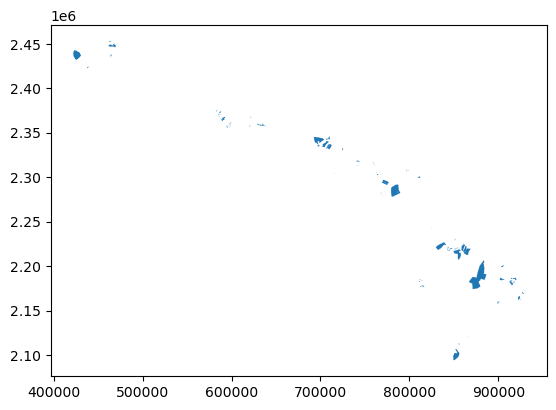

In [22]:
gdf.plot()

In [23]:
# # Test different tolerances
# for tol in [0.0001, 0.0005, 0.001, 0.005, 0.01]:
#     gdf_test = gdf.copy()
#     gdf_test['geometry'] = gdf_test.simplify(tol, preserve_topology=True)
    
#     # Export and check file size
#     # filename = f'hawaii_tol_{tol}.geojson'
#     # gdf_test.to_file(filename, driver='GeoJSON')
    
#     # Visual check - plot to see quality
#     gdf_test.plot()
#     plt.title(f'Tolerance: {tol}')
#     plt.show()

### Process shp/gdf > geojson

In [24]:
# Change to be compatible with leaflet
gdf = gdf.to_crs(epsg=4326)

In [25]:
# Simplify geometry
# Greater tolerance means greater simplification
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.0001, preserve_topology=True)

# Keep only needed columns
gdf_stripped = gdf[['GEOID10', 'NAME10', 'POP10', 'geometry']]

# Export with reduced coordinate precision
gdf_stripped.to_file('~/Desktop/Census_Hawaiian_Homelands_hhl10_Stripped.geojson', 
                  driver='GeoJSON', 
                  coordinate_precision=5)

# gdf.to_file(f'~/Desktop/2020_Census_County_Boundaries.geojson', driver='GeoJSON')

### Quick visualization of gis data

In [ ]:
print(f"Loaded shapefile with {len(gdf)} features")
print(f"Columns: {gdf.columns.tolist()}")
print(f"First row: {gdf.iloc[0]}")

# Create a simple visualization of the block groups
fig, ax = plt.subplots(figsize=(12, 8))

# Color by an existing column in the shapefile - 'pop20' is usually available
# Change 'pop20' to any column that exists in your shapefile
gdf.plot(column='geometry', cmap='Blues', linewidth=0.5, 
         ax=ax, edgecolor='k', legend=True)

# Add a title
plt.title('Census Block Groups')

# Display the map
plt.tight_layout()
plt.show()

# Save the map as an image file
plt.savefig('census_map.png', dpi=300, bbox_inches='tight')
print("Map saved as 'census_map.png'")

## Convert to geoJSON for leaflet

In [ ]:
output_path = './2020_Census_Block_Groups_WGS84.geojson'
gdf.to_file(output_path, driver='GeoJSON')

## Demo download from koa cloud using API

### For env variables, create a .env file with variables and values

In [ ]:
import os
from dotenv import load_dotenv
from nc_py_api import Nextcloud

load_dotenv()

# Get credentials from environment variables
nc_url = os.environ.get("NEXTCLOUD_URL", "")
nc_user = os.environ.get("NEXTCLOUD_USER", "")
nc_pass = os.environ.get("NEXTCLOUD_PASS", "")

# Connect only if credentials are available
if nc_url and nc_user and nc_pass:
    nc = Nextcloud(
        nextcloud_url=nc_url,
        nc_auth_user=nc_user,
        nc_auth_pass=nc_pass
    )
else:
    print("Nextcloud credentials not found in environment variables")

In [ ]:
# nc.files.download("SCOVI Project/Metrics/All Exposures/census/cleaned-data/age_of_structure.csv")

In [ ]:
# pretty_capabilities = dumps(nc.capabilities, indent=4, sort_keys=True)
# print(pretty_capabilities)

In [ ]:
# print("Files & folders on the instance for the selected user:")
# all_files_folders = nc.files.listdir(r"SCOVI Project", depth=-1)
# for obj in all_files_folders:
#     print(obj.user_path)